In [1]:
import os
import numpy as np
from hdf5storage import loadmat, savemat
from numpy import random
import numpy as np
import seaborn as sns
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gamma, norm
from scipy.stats import multivariate_normal as mvn
from numpy.random import default_rng
from sklearn.linear_model import LinearRegression
import pandas as pd
import pickle

Load data

In [26]:
#load 
kn= loadmat('/home/tailai/data/knapsack/runB/kn_3_1_allneg_60_6_3.mat')
kn.keys()

dict_keys(['capacity', 'distribution_table', 'items', 'js_div_list', 'max_no_improve_gen', 'n_con', 'n_items', 'n_obj', 'n_selected', 'pareto_front_final', 'pareto_indices_final', 'pop_size', 'r', 'r_con', 'r_obj', 'rpos', 'scale', 'shape'])

Get useful variables 

In [27]:
n_con = kn['n_con'] #number of constraints
n_items = kn['n_items'] #number of items
n_obj = kn['n_obj'] #number of objectives
n_selected = kn['n_selected'] #number of selected items#get useful variables 
pf = kn['pareto_front_final'] #final pareto front
pi = kn['pareto_indices_final'] #final pareto indices
dt = kn['distribution_table'] #distribution table
items = kn['items'] #item features - objectives and constraints 
n_run = len(items) # number of runs for a set of parameters 


This function transforms any set of items to the normal space.  This is going to be used many times  

In [28]:
def transform_items_to_z(items):
    alpha = np.empty(items.shape[1])
    beta = np.empty(items.shape[1])
    items_z = np.empty(items.shape)
    for i in range(items.shape[1]):#get useful variables 
        a, loc, scale = gamma.fit(items[:, i], floc=0.0)
        alpha[i] = a
        beta[i] = scale
        u = gamma.cdf(items[:,i], a = a, scale = scale)
        u = np.clip(u, 1e-12, 1-1e-12)
        items_z[:,i] = norm.ppf(u) 
    return alpha, beta,items_z

For each of the runs, transform the items to the normal space as items_z and compute the correlation matrix between 

In [29]:
shape = np.empty((n_run,n_obj+n_con))
scale = np.empty((n_run,n_obj+n_con))
items_z = list()
r_items = np.empty((n_run,n_obj+n_con,n_obj+n_con))
for j in range(len(items)):
    items_r = kn['items'][j]
    items_r = items_r+1
    a,b,z = transform_items_to_z(items_r)
    shape[j,:] = a
    scale[j,:] = b
    items_z.append(z)
    r_items[j,:,:]= np.corrcoef(np.transpose(z))

In [30]:
rng = default_rng(seed = 1111)
XX_z_list = []
YY_list = []
for j in range(len(pi)):
    px = pi[j]
    XX = np.empty((px.shape[0],n_selected,n_obj+n_con))
    XX_z = np.empty((px.shape[0],n_selected,n_obj+n_con))
    for k in range(px.shape[0]): 
        qx = rng.permutation(px[k,:])
        XX_z[k,:,:] = items_z[j][qx,:]
        XX[k,:,:] = items[j][qx,:]
    YY = np.cumsum(XX,axis = 1)
    XX_z_list.append(XX_z)
    YY_list.append(YY)

with open("XX_z_list.pkl", "wb") as f:
    pickle.dump(XX_z_list, f, protocol=pickle.HIGHEST_PROTOCOL)

In [33]:
# all runs
rows = []
for n in range(len(YY_list)):
    for j in range(n_selected):
        for k in range(n_obj+n_con):
            if k < n_obj:
                rows.append(pd.DataFrame({
                    'cumulative': YY_list[n][:,j, k],
                    'step': f'Step {j}',
                    'objective': f'Obj {k}',
                    'run': n,
                }))
            else:
                rows.append(pd.DataFrame({
                    'cumulative': YY_list[n][:,j, k],
                    'step': f'Step {j}',
                    'objective': f'Con {k-n_obj}',
                    'run': n,
                }))
df_Y = pd.concat(rows, ignore_index=True)
    

In [32]:
def ecdf(df_table,n_selected,n_obj,n_con):
    nk = len(df_table)/(n_selected*(n_obj+n_con))
    ecdf_table = np.zeros((n_selected,(n_obj+n_con),int(nk)))
    for t in range(1,n_selected):
        for i in range(n_obj+n_con):
            if i < n_obj:
                ecdf_table[t,i,:] = np.sort(df_table['cumulative'][(df_table['objective'] == f'Obj {i}')&(df_table['step'] == f'Step {t}')].values)
            else:
                ecdf_table[t,i,:] = np.sort(df_table['cumulative'][(df_table['objective'] == f'Con {i - n_obj}')&(df_table['step'] == f'Step {t}')].values)
    return ecdf_table


def z_transform_from_ecdf(Y, ecdf_table):
    # assumes runs have been converted to data frame   
    N, d = Y.shape  
    Y_z = np.empty_like(Y)
    
    for t in range(1,N):
        for i in range(d):
            ranks = np.searchsorted(ecdf_table[t,i,:], Y[t, i], side='right')
            u = ranks / len(ecdf_table[t,i,:])
            u = np.clip(u, 1e-12, 1 - 1e-12)
            Y_z[t, i] = norm.ppf(u)
    return Y_z

In [34]:
ecdf_table = ecdf(df_Y,n_selected,n_obj,n_con)
YY_z_list = []
for j in range(len(YY_list)): 
    YY = YY_list[j]
    YY_z = np.empty_like(YY)
    for k in range(YY.shape[0]):
        YY_z[k] = z_transform_from_ecdf(YY[k],ecdf_table)
        YY_z[k,0,:] = XX_z_list[j][k,0,:]
    YY_z_list.append(YY_z)
    print("run", j, "done")
with open("YY_z_list.pkl", "wb") as f:
    pickle.dump(YY_z_list, f, protocol=pickle.HIGHEST_PROTOCOL)

run 0 done
run 1 done
run 2 done
run 3 done
run 4 done
run 5 done
run 6 done
run 7 done
run 8 done
run 9 done
run 10 done
run 11 done
run 12 done
run 13 done
run 14 done
run 15 done
run 16 done
run 17 done
run 18 done
run 19 done
run 20 done
run 21 done
run 22 done
run 23 done
run 24 done
run 25 done
run 26 done
run 27 done
run 28 done
run 29 done
run 30 done
run 31 done
run 32 done
run 33 done
run 34 done
run 35 done
run 36 done
run 37 done
run 38 done
run 39 done
run 40 done
run 41 done
run 42 done
run 43 done
run 44 done
run 45 done
run 46 done
run 47 done
run 48 done
run 49 done
run 50 done
run 51 done
run 52 done
run 53 done
run 54 done
run 55 done
run 56 done
run 57 done
run 58 done
run 59 done
run 60 done
run 61 done
run 62 done
run 63 done
run 64 done
run 65 done
run 66 done
run 67 done
run 68 done
run 69 done
run 70 done
run 71 done
run 72 done
run 73 done
run 74 done
run 75 done
run 76 done
run 77 done
run 78 done
run 79 done
run 80 done
run 81 done
run 82 done
run 83 done
ru

In [6]:
with open("XX_z_list.pkl", "rb") as f:
    XX_z_list = pickle.load(f)
with open("YY_z_list.pkl", "rb") as f:
    YY_z_list = pickle.load(f)

CPFN (the probability of selecting item x at step t given all previous selections)

In [35]:
from dlroms import*
from generative import PushForward
from dlroms.dnns import Reshape
import torch

In [36]:
X = np.vstack(XX_z_list[0:160])
Y = np.vstack(YY_z_list[0:160])

In [37]:
X.shape

(67351, 6, 4)

In [38]:
L, r = 50, 50
d, q = X.shape[-1], Y.shape[-1]
phi = Dense(d, L, gelu) + Dense(L, L, gelu) + Dense(L, L, gelu) + Dense(L, r*q, None) + Reshape(r, q)
psi = Dense(q, L, gelu) + Dense(L, L, gelu) + Dense(L, L, gelu) + Dense(L, r*q, gelu) + Reshape(r, q)
cpfn = PushForward(phi, psi)
cpfn.cuda()

In [12]:
# X given previous Xs
def train_cpfn(X):
    X = torch.as_tensor(X, device="cuda", dtype=torch.float32)
    K, N, d = X.shape

    for t in range(1, N):
        x = X[:, :t, :].reshape(K, -1)
        y = X[:, t, :]

        cpfn.fit(x, y, epochs = 50, lr = 1e-3, m = 100, h0 = 5e-2)

In [39]:
# X given Y
def train_cpfn(X, Y):
    X = torch.as_tensor(X, device="cuda", dtype=torch.float32)
    Y = torch.as_tensor(Y, device="cuda", dtype=torch.float32)
    K, N, d = X.shape

    for t in range(1, N):
        x = Y[:, t-1, :]
        y = X[:, t, :]

        cpfn.fit(x, y, epochs = 50, lr = 1e-3, m = 100, h0 = 5e-2, batchsize = 512)
        cpfn.save(f"trained/test{t}")

In [ ]:
# test training 
w0 = cpfn[0][0].lin.weight.detach().clone()
X = torch.as_tensor(X, device="cuda", dtype=torch.float32)
Y = torch.as_tensor(Y, device="cuda", dtype=torch.float32)
x = Y[:, 0, :]
y = X[:, 1, :]
cpfn.fit(x, y, epochs=20, lr=1e-3, m=10, batchsize=256)
w1 = cpfn[0][0].lin.weight.detach().clone()
print("weight change L2:", (w1 - w0).norm().item())

In [40]:
train_cpfn(X, Y)

		Train		Test
Epoch 44:	4.87e+00	nan.

>> ETA: 13.42s.

Current h: [3.68e-01, 3.64e-01, 3.81e-01, 7.92e-01]


KeyboardInterrupt: 

In [16]:
X_test = np.vstack(XX_z_list[160:])
Y_test = np.vstack(YY_z_list[160:])

In [17]:
# evaluate
from sklearn.metrics import r2_score
def test_cpfn(cpfn, X, Y):
    # X = torch.as_tensor(X, device="cuda", dtype=torch.float32)
    Y = torch.as_tensor(Y, device="cuda", dtype=torch.float32)
    K, N, d = X.shape   

    for t in range(1, N):
        x_true = Y[:, t-1, :]
        y_true = X[:, t, :]

        cpfn.load(f"trained/test{t}")
        y_sampled_batches = []
        for i in range(0, x_true.shape[0], 512):
            x_true_batch = x_true[i:i+512, :]
            y_sampled_batch = cpfn.sample(x_true_batch, m = 100)
            y_sampled_batches.append(y_sampled_batch.detach().cpu().numpy())

        y_sampled = np.concatenate(y_sampled_batches, axis=0)
        
        # diagnostic
        y_expected = y_sampled.mean(axis=1)
        r2 = r2_score(y_true, y_expected)
        print(f"R2 at step {t}: {r2}")
        err = ((y_sampled - y_true[:,None,:])**2).sum(axis=-1) 
        y_best = y_sampled[np.arange(K), err.argmin(axis=1)]   
        print("R2(best sample):", r2_score(y_true, y_best))

        # plot distribution (objective space)
        samples = y_sampled[0, :, 0] # (m,)
        true_values = y_true[0, 0]

        plt.figure(figsize=(6, 4))
        plt.hist(samples, bins=30, density=True, alpha=0.6)
        plt.axvline(true_values, color='r', linestyle='--', label='true y')
        plt.axvline(samples.mean(), color='k', label='mean')
        plt.axvline(np.median(samples), color='g', label='median')
        plt.legend()
        plt.show()

R2 at step 1: -0.2819389546442141
R2(best sample): 0.715566327696207


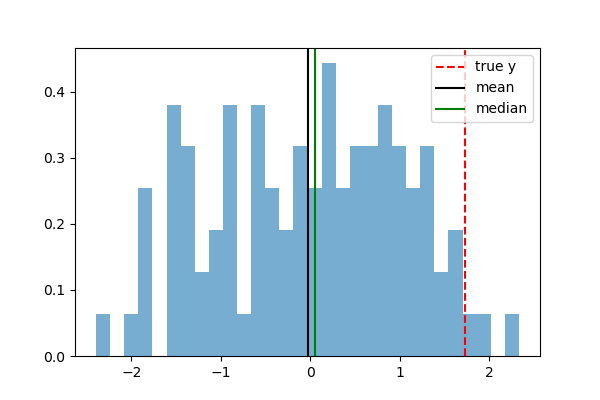

R2 at step 2: -0.3265289752411862
R2(best sample): 0.6862134159985973


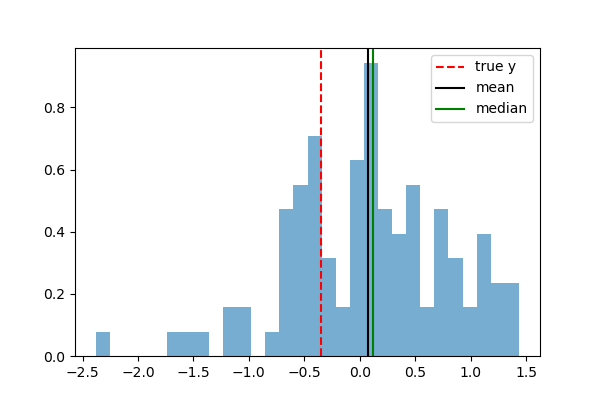

R2 at step 3: -0.25286776926031473
R2(best sample): 0.7231954830719192


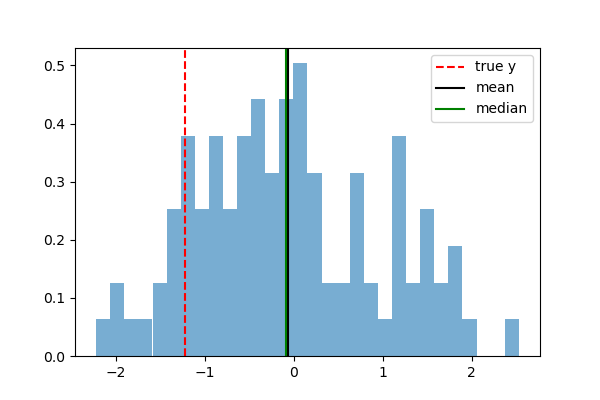

R2 at step 4: -0.2359406733888523
R2(best sample): 0.7235282974624223


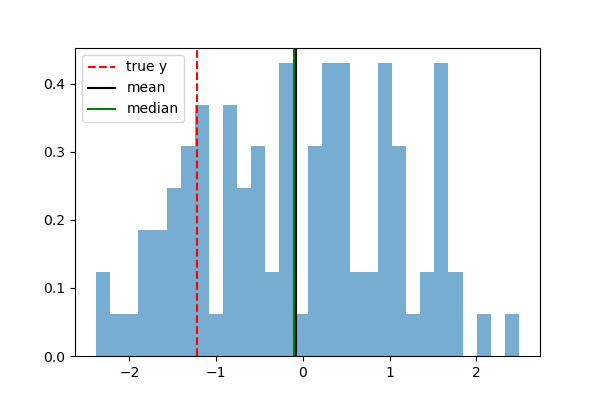

R2 at step 5: -0.1721352797681788
R2(best sample): 0.7464219483008215


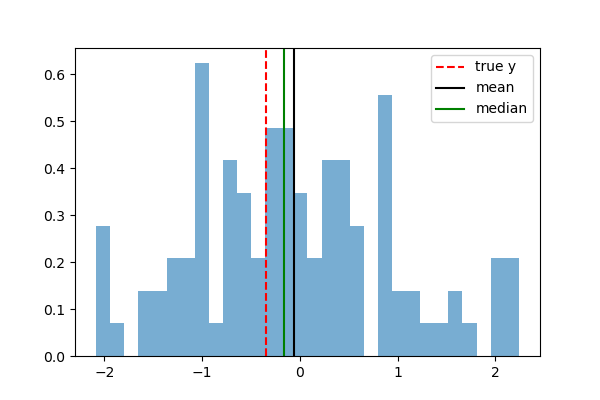

In [18]:
test_cpfn(cpfn, X_test, Y_test)

In [19]:
# plot distribution (item space)
y_ex = items_z[161][np.setdiff1d(np.arange(n_items),pi[161][10, 0:3]),:]
y_ex = torch.as_tensor(y_ex, device="cuda", dtype=torch.float32)
x_ex = YY_z_list[161][10, 4, :]
x_ex = torch.as_tensor(x_ex, device="cuda", dtype=torch.float32)

t = 5
cpfn.load(f"trained/test{t}")
# y_sampled = cpfn.sample(x_ex, m = 100).detach().cpu().numpy()
# y_mean = y_sampled.mean(axis=1).squeeze()
# y_var = np.cov(y_sampled.reshape(-1, d).T)
# densities = mvn.pdf(y_ex, mean=y_mean, cov=y_var)
y_samples = cpfn.sample(x_ex, m = 100)
densities = cpfn.density(y_samples, y_ex).detach().cpu().numpy()

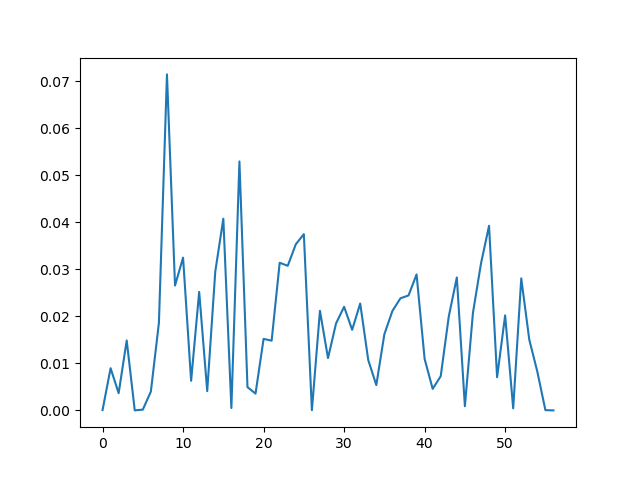

In [20]:
plt.figure()
plt.plot(densities/sum(densities))
plt.show()

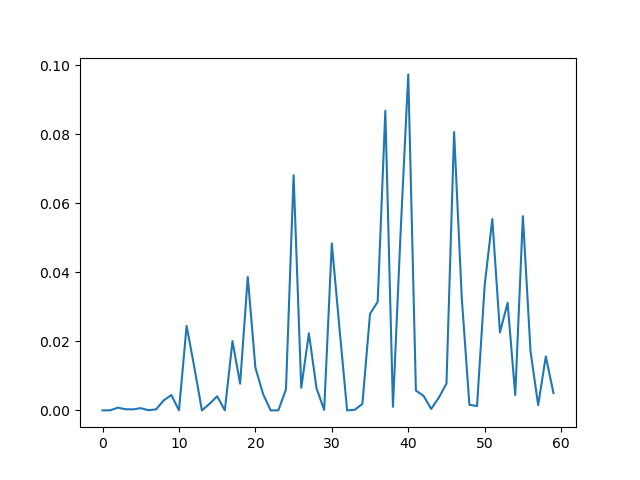

In [21]:
def base_rate_model(items_z, XX_0):
    mean0 = np.mean(XX_0, axis = 0)
    Sigma0 = np.cov(XX_0.T) #python is stupid
    mvn0 = mvn(mean=mean0, cov=Sigma0)
    x_candidates = items_z
    probabilities = mvn0.pdf(x_candidates)
    probabilities = (probabilities+1e-12)/sum(probabilities+1e-12)
    return probabilities
probabilities = base_rate_model(items_z[100],np.vstack(XX_z_list)[:,0,:])
plt.figure()
plt.plot(probabilities)

In [22]:
def cond_density(y_ex, x_ex, cpfn, t):
    x_ex = torch.as_tensor(x_ex, device="cuda", dtype=torch.float32)
    y_ex = torch.as_tensor(y_ex, device="cuda", dtype=torch.float32)
    cpfn.load(f"trained/test{t}")
    
    # y_sampled = cpfn.sample(x_ex, m = 100).detach().cpu().numpy()
    # y_mean = y_sampled.mean(axis=1).squeeze()
    # y_var = np.cov(y_sampled.reshape(-1, d).T)
    # densities = mvn.pdf(y_ex, mean=y_mean, cov=y_var)
    y_samples = cpfn.sample(x_ex, m = 1000)
    densities = cpfn.density(y_samples, y_ex).detach().cpu().numpy()
    return densities

In [23]:
domination_score = np.zeros(40)
for kk in range(40):
    k = kk+160
    probabilities = base_rate_model(items_z[k],np.vstack(XX_z_list[0:160])[:,0,:])
    knapsack_indices = np.zeros(n_selected, dtype=int)
    knapsack = np.zeros((n_selected,(n_obj+n_con)))
    first_choice = np.argmax(probabilities)
    first_item = items_z[k][first_choice,:]
    x_indices = np.setdiff1d(np.arange(n_items),knapsack_indices)
    y_prev = first_item 
    knapsack[0,:] = items[k][first_choice,:]
    knapsack_indices[0] = first_choice
    for n in range(1,n_selected):
        x_indices = np.setdiff1d(np.arange(n_items),knapsack_indices[0:n])
        x_candidates = items_z[k][x_indices,:]
        densities = cond_density(x_candidates, y_prev, cpfn, t=n)
        probabilities = densities/sum(densities)
        next_choice = np.argmax(probabilities)
        next_index = x_indices[next_choice]
        next_item = items_z[k][next_index,:]
        knapsack[n,:] = items[k][next_index,:]
        knapsack_indices[n] = next_index
        y_prev = y_prev + next_item
  
    pf_predicted = np.sum(knapsack, axis=0)
    pf_actual = pf[k]
    count = 0 
    for j in range(pf_actual.shape[0]):
        if np.any(pf_predicted[0:2] > pf_actual[j,0:2]):
            count = count + 1 
    domination_score[kk]= 1-count/pf_actual.shape[0]


In [24]:
domination_score

array([0.83236994, 0.68037975, 0.72469636, 0.98958333, 0.76      ,
       0.98941799, 0.61890244, 0.76530612, 0.78494624, 0.85067873,
       0.8238806 , 0.66240409, 0.875     , 0.86842105, 0.9005848 ,
       0.84353741, 0.77286136, 0.78595318, 0.86387435, 0.55399061,
       0.97472924, 0.7016129 , 0.9010989 , 0.79723502, 0.95473251,
       0.71167883, 0.93548387, 0.95187166, 0.87449393, 0.80786026,
       0.75767918, 0.95789474, 0.77777778, 0.87619048, 0.85849057,
       0.97333333, 0.81368821, 0.98717949, 0.74897119, 0.86486486])

In [25]:
np.mean(domination_score)

np.float64(0.8293413825039353)